# SurEau climate
 

In [ ]:
# | default_exp sureau_climate

The overall goal of SurEau Climate is to generate hourly forcings from daily 
climatic variables 

```
 Input: climate_df (DataFrame with daily records),
          date string (DD/MM/YYYY)
                         │
                         ▼
    ┌────────────────────────────────────────────┐
    │  new_climate_day(climate_df, date)         │
    │                                            │
    │  1. Parse date string → DOY, year          │
    │     (dateutil.parser handles any format)   │
    │                                            │
    │  2. Slice row where DATE == date           │
    │                                            │
    │  3. Assign met fields:                     │
    │     T_mean, T_min, T_max                   │
    │     RH_mean, RH_min, RH_max                │
    │     PPT, RG, WS_mean                       │
    │                                            │
    │  4. VPD = f(RH_mean, T_mean)               │
    │                                            │
    │                                            │
    │  5. Look up prev/next row by integer pos   │
    │     → T_min_prev, T_max_prev, T_min_next   │
    │     (needed for diurnal T model)           │
    └────────────────────────────────────────────┘
                          │
                          ▼  
                 SurEauClimate object
    ┌────────────────────────────────────────────┐
    │  compute_Rn_and_ETP(clim, params, opts)    │
    │                                            │
    │  Branch: opts.Rn_formulation               │
    │  ─────────────────────────────             │
    │  "Linacre":                                │
    │    nN = 0.25 if PPT > 0 else 0.75          │
    │    (cloud proxy: rainy=cloudy, dry=clear)  │
    │                                            │
    │    SW_abs = (1 − 0.17) × RG × 10⁶          │
    │    LW_loss = 1927.987 × (1+4·nN)           │
    │             × (100 − T_mean)               │
    │                                            │
    │    Rn = max(0,  SW_abs − LW_loss ) × 10⁻⁶  │
    │                                            │
    │  ETP_formulation                           │
    │  ─────────────────────────────             │
    │  "PT": Priestley-Taylor                    │
    │    ETP = α × Δ·Rn / [λ(Δ+γ)]               │
    │    via pyet.priestley_taylor()             │
    │    (α = params.PT_coeff ≈ 1.14)            │
    │                                            │
    │  "PM": Penman-Monteith                     │
    │    es = pyet.calc_es(T)                    │
    │    ea = es − VPD                           │
    │    ETP = pyet.pm(T, WS, Rn, ea, elev)      │
    └────────────────────────────────────────────┘
                         │
                         ▼  
            clim.net_radiation, clim.ETP set
    ┌────────────────────────────────────────────┐
    │ new_climate_hourly(clim, opts, veg_params) │
    │                                            │
    │  1. Daylength & solar geometry             │
    │     sunrise_h, sunset_h, daylen_h          │
    │     = daylength(opts.latitude, clim.DOY)   │
    │     Polar edge cases clamped to [0, 24]    │
    │                                            │
    │  2. Radiation disaggregation               │
    │     time_rel = hour × 3600 − sunrise_s     │
    │     io = π/daylen × sin(π·t_rel/daylen)    │
    │     io = 0 outside [sunrise, sunset]       │
    │     RG_h  = RG  × io × 3600  [MJ m⁻² h⁻¹]  │
    │     Rn_h  = Rn  × io × 3600                │
    │                                            │
    │  3. PAR                                    │
    │     PAR_h = PPFD(Watt(RG_h))               │
    │     pot_PAR_h = potential_PAR(h, lat, DOY) │
    │                                            │
    │  4. Temperature disaggregation             │
    │     Parton & Logan model per hour:         │
    │     • Daytime: sine ramp Tmin → Tmax       │
    │     • Evening: exp decay → T_min_next      │
    │     Uses T_min_prev, T_max_prev,           │
    │          T_min_next from adjacent days     │
    │                                            │
    │  5. Relative humidity disaggregation       │
    │     Dewpoint ≈ Tmin (RH_max at sunrise)    │
    │     ea = RH_max/100 × es(Tmin)             │
    │     RH_h = ea / es(T_h) × 100              │
    │     Clipped to [0.5, 100] %                │
    │                                            │
    │  6. Wind speed                             │
    │     WS_h = WS_mean (constant across hours) │
    │                                            │
    │  7. VPD_h = f(RH_h, T_h) per hour          │
    │                                            │
    │  8. ETP disaggregation                     │
    │     "PT": pyet.priestley_taylor(           │
    │              T_h, Rn_h, α, elev)           │
    │     "PM": pyet.pm(T_h, WS_h, Rn_h,         │
    │              ea_h, elev)                   │
    │                                            │
    │  9. Time-step duration n_h                 │
    │     n_h[0]   = ts[0] + (24 − ts[-1])       │
    │     n_h[i>0] = ts[i] − ts[i-1]             │
    │                                            │
    │  10. Subset to opts.time_steps             │
    │      (full 24 h or custom sub-hourly idx)  │
    │                                            │
    │  11. PPT assigned to first time step only  │
    └────────────────────────────────────────────┘
                          │
                          ▼  
                 SurEauClimateHourly 
                     object (ch)
      
                          │
                ┌─────────┴──────────┐
                │ Two parallel uses: │
                ▼                    ▼
    ┌───────────────┐  ┌──────────────────────────────────────┐
    │ get_hourly_   │  │  interpolate_climate_hourly(         │
    │ snapshot(     │  │      ch1_arrays, ch2_arrays, p=0.5)  │
    │   ch, idx)    │  │                                      │
    │               │  │  Linear blend between two snapshots: │
    │  Extracts one │  │  field = (1−p)·ch1[f] + p·ch2[f]     │
    │  timestep as  │  │                                      │
    │  a plain dict │  │  Interpolated fields:                │
    │  for passing  │  │  T_air_mean, RG, WS, VPD,            │
    │  into the     │  │  RH_air_mean, ETP, ETP_veg*          │
    │  hydraulic    │  │  (*if present in both snapshots)     │
    │  solver       │  │                                      │
    │               │  │  Non-interpolated fields copied      │
    │  Keys:        │  │  verbatim from ch1                   │
    │  T, RG, WS,   │  │                                      │
    │  VPD, RH,     │  │  Used to refine forcing between      │
    │  ETP, PAR,    │  │  two stored hourly time steps        │
    │  pot_PAR,     │  └──────────────────────────────────────┘
    │  n_hours,     │
    │  time         │
    └───────────────┘
                      │
                      ▼
       Returns:
       • new_climate_day()            → SurEauClimate object
       • compute_Rn_and_ETP()         → SurEauClimate object (Rn + ETP added)
       • new_climate_hourly()         → SurEauClimateHourly object
                                        (RG, Rn, PAR, T, RH, WS, VPD, ETP,
                                         time, n_hours, PPT arrays)
       • get_hourly_snapshot()        → dict (single timestep)
       • interpolate_climate_hourly() → dict (blended between two snapshots)
```

In [ ]:
# | hide
import itables
from fastcore import *
from nbdev.showdoc import *

In [ ]:
# | hide
itables.init_notebook_mode(all_interactive=True)

In [ ]:
# | export

import pyet
import numpy as np
import pandas as pd
from dateutil import parser
import matplotlib.pyplot as plt
from plant_hydraulics.parameter_classes import (
    SurEauClimate,
    SurEauClimateHourly,
    SurEauModelOptions,
    SurEauVegetationParams,
)
from plant_hydraulics.utils import (
    daylength,
    rh_diurnal,
    compute_VPD,
    Rg_MJ_to_Watt,
    potential_PAR,
    Rg_Watt_to_PPFD,
    # get_elevation,
    # compute_ETP_PT,
    # compute_ETP_PM,
    load_example_data,
    list_example_data,
    temperature_diurnal,
    radiation_diurnal_pattern,
)

In [ ]:
# | export
def new_climate_day(climate_df: pd.DataFrame, date: int) -> SurEauClimate:
    """Extract daily climate from each row of a DataFrame

    The column names in the data frame __MUST__ be named as the following:

    - DATE: Date with format DD/MM/YYYY
    - Tair_mean: Air temperature mean (degress C)
    - Tair_max: Maximum air temperature (degress C)
    - Tair_min: Minimum air temperature (degress C)
    - RHair_mean: Mean relative humidity of the day (%)
    - RHair_max: Maximum relative humidity of the day (%)
    - RHair_min: Minimum relative humidity of the day (%)
    - PPT_sum: Precipitation (mm)
    - RG_sum: Global radiation (MJ/m2)
    - WS_mean: Mean wind speed of the day (m/s)

    """

    # Normalize the input date to a datetime object, regardless of format
    parsed_date = parser.parse(date)

    # Initialize class climate --------------------------------------------------
    clim = SurEauClimate()

    # Get the possition of the row given the date -------------------------------
    idx = climate_df["DATE"] == date
    row = climate_df.loc[idx]

    # Check row of the dataframe ------------------------------------------------
    if len(row) == 0:
        raise ValueError(f"No climate data for {date}")

    # Extract data from each column in each row ---------------------------------
    # and asssing it to the SurEauClimate() object
    row = row.iloc[0]
    clim.DOY = parsed_date.timetuple().tm_yday
    clim.year = parsed_date.year
    clim.date = str(row.get("DATE", ""))
    clim.T_air_mean = row["Tair_mean"]
    clim.T_air_max = row["Tair_max"]
    clim.T_air_min = row["Tair_min"]
    clim.RH_air_mean = row["RHair_mean"]
    clim.RH_air_max = row["RHair_max"]
    clim.RH_air_min = row["RHair_min"]
    clim.PPT = row["PPT_sum"]
    clim.RG = row["RG_sum"]
    clim.WS_mean = row["WS_mean"]

    # Compute VPD ---------------------------------------------------------------
    clim.VPD = compute_VPD(clim.RH_air_mean, clim.T_air_mean)

    # Get Previous/next day temperatures ----------------------------------------
    row_idx = row.name
    all_idx = climate_df.index
    pos = (
        all_idx.get_loc(row_idx)
        if hasattr(all_idx, "get_loc")
        else list(all_idx).index(row_idx)
    )
    if pos > 0:
        prev = climate_df.iloc[pos - 1]
        clim.T_air_min_prev = prev["Tair_min"]
        clim.T_air_max_prev = prev["Tair_max"]
    else:
        clim.T_air_min_prev = clim.T_air_min
        clim.T_air_max_prev = clim.T_air_max

    if pos < len(climate_df) - 1:
        nxt = climate_df.iloc[pos + 1]
        clim.T_air_min_next = nxt["Tair_min"]
    else:
        clim.T_air_min_next = clim.T_air_min

    return clim

In [ ]:
# | export
def compute_Rn_and_ETP(
    clim: SurEauClimate,
    params: SurEauVegetationParams,
    opts: SurEauModelOptions,
) -> SurEauClimate:
    """Compute daily net radiation and PET.

    Given today's solar radiation, precipitation, and temperature —
    how much energy is available at the surface, and how much water
    could potentially evaporate?"

    Both outputs are stored back into clim and returned for use in the rest of
    the model.

    Physics notes:

    -Rn: Linacre (1968) formulation:
            shortwave absorbed = (1 - 0.17) × RG
            longwave loss      = 1927.987 × (1 + 4·nN) × (100 - T_mean)
            nN = 0.25 if PPT > 0 else 0.75

    -ETP: Priestley-Taylor: ETP = α × Δ·Rn / λ(Δ+γ)

    """
    if opts.Rn_formulation == "Linacre":
        # Cloud cover proxy nN based on whether it rained that day.
        # The logic is: if it's raining the sky is cloudy (nN = 0.25),
        # if it's dry the sky is clear (nN = 0.75).

        # If Precipitation is larger than 0...
        nN = 0.25 if clim.PPT > 0 else 0.75

        # Compute net radiation -------------------------------------------------
        # Incoming shortwave minus outgoing longwave --
        clim.net_radiation = max(
            0,
            1e-6
            * (
                # Absorbed solar radiation (0.17 is the surface albedo,
                # so 83% of incoming radiation RG is absorbed)
                (1 - 0.17) * 1e6 * clim.RG
                # Longwave radiation lost to the atmosphere, which increases
                # with cloud cover (nN) and decreases with temperature
                - 1927.987 * (1 + 4 * nN) * (100 - clim.T_air_mean)
            ),
        )

    # Compute ETP ---------------------------------------------------------------
    if opts.ETP_formulation == "PT":
        # clim.ETP = compute_ETP_PT(clim.T_air_mean, clim.net_radiation, params.PT_coeff)
        clim.ETP = pyet.priestley_taylor(
            pd.Series([clim.T_air_mean]),
            rn=pd.Series([clim.net_radiation]),
            elevation=opts.elevation,
            alpha=params.PT_coeff,
        ).iloc[0]
    else:
        print(f"ETP_formulation is {opts.ETP_formulation}")

    return clim

In [ ]:
# | export
def new_climate_hourly(
    clim: SurEauClimate,
    opts: SurEauModelOptions,
    veg_params: SurEauVegetationParams,
) -> SurEauClimateHourly:
    """Disaggregate daily climate to sub-daily time steps."""
    # Init object ---------------------------------------------------------------
    climate_hourly_ch = SurEauClimateHourly()

    # Time step paramets --------------------------------------------------------
    time_idx = opts.time_steps.astype(int)
    ts = opts.time_steps.astype(float)

    # Define daylength ----------------------------------------------------------
    if opts.constant_climate:
        sunrise_h, sunset_h, daylen_h = daylength(0, 116)
    else:
        sunrise_h, sunset_h, daylen_h = daylength(opts.latitude, clim.DOY)

    if daylen_h >= 24:
        sunrise_h, sunset_h, daylen_h = 0.0, 24.0, 24.0
    elif daylen_h <= 0:
        sunrise_h, sunset_h, daylen_h = 12.0, 12.0, 0.0

    # Transform to seconds ------------------------------------------------------
    sunrise_s = sunrise_h * 3600
    sunset_s = sunset_h * 3600
    daylen_s = daylen_h * 3600

    TIME_HOUR = np.arange(24, dtype=float)
    time_rel = TIME_HOUR * 3600 - sunrise_s

    # Radiation pattern ---------------------------------------------------------
    io = np.array([radiation_diurnal_pattern(t, daylen_s) for t in time_rel])
    io[(time_rel < 0) | (TIME_HOUR * 3600 >= sunset_s)] = 0.0

    RG_h = clim.RG * io * 3600
    Rn_h = clim.net_radiation * io * 3600
    PAR_h = Rg_Watt_to_PPFD(Rg_MJ_to_Watt(RG_h, N_hours=1))
    pot_PAR_h = potential_PAR(TIME_HOUR, opts.latitude, clim.DOY)

    # Create diurnal temperature pattern ----------------------------------------
    T_h = np.array(
        # Comprehension list with hourly temperature
        [
            temperature_diurnal(
                each_temp,
                clim.T_air_min,
                clim.T_air_max,
                clim.T_air_min_prev,
                clim.T_air_max_prev,
                clim.T_air_min_next,
                daylen_s,
            )
            for each_temp in time_rel
        ]
    )

    # Create relative humidity values  pattern ----------------------------------
    RH_h = np.array(
        # Comprehension list with hourly relative humidity values
        [
            rh_diurnal(
                T,
                clim.T_air_min,
                clim.T_air_max + 1e-7,
                clim.RH_air_min,
                clim.RH_air_max + 1e-6,
            )
            for T in T_h
        ]
    )

    # Limit the values in an array to a specified range by replacing values
    # outside the range with the nearest interval edge
    RH_h = np.clip(RH_h, 0.5, 100.0)

    # Creates a new array of a specified shape and fills it entirely with a
    # constant value.
    WS_h = np.full(24, clim.WS_mean)

    # Compute hourly VPD --------------------------------------------------------
    VPD_h = compute_VPD(RH_h, T_h)

    # Compute hourly ETP --------------------------------------------------------
    if opts.ETP_formulation == "PT":
        # Old
        # ETP_h = compute_ETP_PT(T_h, Rn_h, veg_params.PT_coeff)

        ETP_h = pyet.priestley_taylor(
            pd.Series(T_h),
            rn=pd.Series(Rn_h),
            alpha=veg_params.PT_coeff,
            # needed to compute psychrometric constantγ
            elevation=opts.elevation,
        ).values

    else:
        # Old
        # ETP_h = compute_ETP_PM(T_h, Rn_h, clim.WS_mean, clim.VPD)

        # Derive actual vapour pressure from VPD
        # VPD = es - ea  →  ea = es - VPD
        # es (saturation VP) can be computed from temperature

        # [kPa], uses Tetens equation internally
        es = pyet.calc_es(T_h)

        # [kPa], actual vapour pressure
        ea = es - pd.Series(VPD_h)

        # Call pyet.pm
        print("Remember to adjust the lat/lon")
        ETP_h = pyet.pm(
            tmean=pd.Series(T_h),
            wind=pd.Series(WS_h),
            rn=pd.Series(Rn_h),
            ea=ea,
            # needed to compute psychrometric constant γ
            elevation=opts.elevation,
        ).values

    # Compute duration of each time step in hours -------------------------------
    n_h = np.zeros(len(ts))

    n_h[0] = ts[0] + (24 - ts[-1]) if len(ts) > 1 else 24.0

    for i in range(1, len(ts)):
        n_h[i] = ts[i] - ts[i - 1]

    # Subset to requested time steps --------------------------------------------
    # Update SurEauClim object with the hourly values

    if len(time_idx) < 24:
        climate_hourly_ch.RG = RG_h[time_idx]
        climate_hourly_ch.Rn = Rn_h[time_idx]
        climate_hourly_ch.PAR = PAR_h[time_idx]
        climate_hourly_ch.potential_PAR = pot_PAR_h[time_idx]
        climate_hourly_ch.T_air_mean = T_h[time_idx]
        climate_hourly_ch.RH_air_mean = RH_h[time_idx]
        climate_hourly_ch.WS = WS_h[time_idx]
        climate_hourly_ch.VPD = VPD_h[time_idx]
        climate_hourly_ch.ETP = ETP_h[time_idx]
    else:
        climate_hourly_ch.RG, climate_hourly_ch.Rn, climate_hourly_ch.PAR = (
            RG_h,
            Rn_h,
            PAR_h,
        )
        climate_hourly_ch.potential_PAR = pot_PAR_h
        climate_hourly_ch.T_air_mean, climate_hourly_ch.RH_air_mean = T_h, RH_h
        climate_hourly_ch.WS, climate_hourly_ch.VPD, climate_hourly_ch.ETP = (
            WS_h,
            VPD_h,
            ETP_h,
        )

    climate_hourly_ch.time = ts
    climate_hourly_ch.n_hours = n_h
    climate_hourly_ch.PPT = np.zeros(len(ts))
    climate_hourly_ch.PPT[0] = clim.PPT

    return climate_hourly_ch

In [ ]:
# | export


def interpolate_climate_hourly(ch1_arrays: dict, ch2_arrays: dict, p=0.5) -> dict:
    """Linearly interpolate between two hourly climate snapshots."""
    res = {}

    for each_key in ["T_air_mean", "RG", "WS", "VPD", "RH_air_mean", "ETP"]:
        if each_key in ch1_arrays and each_key in ch2_arrays:
            res[each_key] = (1 - p) * ch1_arrays[each_key] + p * ch2_arrays[each_key]

    if "ETP_veg" in ch1_arrays and "ETP_veg" in ch2_arrays:
        res["ETP_veg"] = (1 - p) * ch1_arrays["ETP_veg"] + p * ch2_arrays["ETP_veg"]

    # Copy non-interpolated fields
    for each_key in ch1_arrays:
        if each_key not in res:
            res[each_key] = ch1_arrays[each_key]
    return res

In [ ]:
# | export
def get_hourly_snapshot(ch: SurEauClimateHourly, idx: int) -> dict:
    """Extract a single timestep from ClimateHourly as a dict."""
    return {
        "T_air_mean": ch.T_air_mean[idx],
        "RG": ch.RG[idx],
        "WS": ch.WS[idx],
        "VPD": ch.VPD[idx],
        "RH_air_mean": ch.RH_air_mean[idx],
        "ETP": ch.ETP[idx],
        "PAR": ch.PAR[idx],
        "potential_PAR": ch.potential_PAR[idx],
        "n_hours": ch.n_hours[idx],
        "time": ch.time[idx],
    }

### Example: Generate hourly forcings using daily values for SurEau

In [ ]:
# List available example files
#list_example_data()

ModuleNotFoundError: No module named 'bonan_hydraulics'

In [ ]:
# Load example data
climate_df = load_example_data("climat_example.csv", sep=";")
itables.show(climate_df)

ModuleNotFoundError: No module named 'bonan_hydraulics'

In [ ]:
# Convert numeric columns (all except DATE)
for each_col in climate_df.columns:
    if each_col != "DATE":
        climate_df[each_col] = pd.to_numeric(climate_df[each_col], errors="coerce")

#### Configure options and vegetation parameters

In [ ]:
# Model options
opts = SurEauModelOptions(
    # ° N  (site location — adjust to your site)
    latitude=43.6,
    # ← metres above sea level
    # SurEauModelOptions.elevation
    # elevation = 150,
    # ° E
    longitude=3.8,
    # net radiation model: "Linacre" (only option currently)
    Rn_formulation="Linacre",
    # PET model: "PT" (Priestley-Taylor) or "PM" (Penman-Monteith)
    ETP_formulation="PT",
    # True → forces a fixed doy=116 (sunny day template)
    constant_climate=False,
    # which hours to output (0–23 → full day)
    time_steps=np.arange(24),
)

In [ ]:
# Vegetation parameters
veg_params = SurEauVegetationParams(
    # Priestley-Taylor α.  Standard = 1.26; tropical humid ≈ 1.1–1.3
    PT_coeff=1.14,
)

#### Extract a single day with new_climate_day()

In [ ]:
target_date = "01/06/1990"  # ← change to any date in the CSV

clim = new_climate_day(climate_df, target_date)

#### Compute Rn and ETP with compute_Rn_and_ETP()

In [ ]:
clim = compute_Rn_and_ETP(clim, veg_params, opts)
print(f"\n  Net radiation (Rn)  : {clim.net_radiation:.4f} MJ m⁻² day⁻¹")
print(f"  PET (ETP)           : {clim.ETP:.4f} mm day⁻¹")


  Net radiation (Rn)  : 22.8024 MJ m⁻² day⁻¹
  PET (ETP)           : 6.7291 mm day⁻¹


#### Disaggregate to hourly with new_climate_hourly()

In [ ]:
hourly_ch = new_climate_hourly(clim, opts, veg_params)

In [ ]:
print(f"\n  Output arrays (24 h each):")
print(
    f"    ch.T_air_mean  [°C]         : {hourly_ch.T_air_mean.min():.1f} – {hourly_ch.T_air_mean.max():.1f}"
)
print(
    f"    ch.RH_air_mean [%]          : {hourly_ch.RH_air_mean.min():.1f} – {hourly_ch.RH_air_mean.max():.1f}"
)
print(
    f"    ch.RG          [MJ m⁻² h⁻¹]: {hourly_ch.RG.min():.3f} – {hourly_ch.RG.max():.3f}"
)
print(
    f"    ch.Rn          [MJ m⁻² h⁻¹]: {hourly_ch.Rn.min():.3f} – {hourly_ch.Rn.max():.3f}"
)
print(
    f"    ch.VPD         [kPa]        : {hourly_ch.VPD.min():.3f} – {hourly_ch.VPD.max():.3f}"
)
print(
    f"    ch.ETP         [mm h⁻¹]     : {hourly_ch.ETP.min():.4f} – {hourly_ch.ETP.max():.4f}"
)
print(
    f"    ch.PAR         [µmol m⁻² s⁻¹]: {hourly_ch.PAR.min():.0f} – {hourly_ch.PAR.max():.0f}"
)


  Output arrays (24 h each):
    ch.T_air_mean  [°C]         : 7.5 – 25.1
    ch.RH_air_mean [%]          : 29.6 – 94.2
    ch.RG          [MJ m⁻² h⁻¹]: 0.000 – 4.791
    ch.Rn          [MJ m⁻² h⁻¹]: 0.000 – 3.867
    ch.VPD         [kPa]        : 0.060 – 2.245
    ch.ETP         [mm h⁻¹]     : 0.0000 – 1.2852
    ch.PAR         [µmol m⁻² s⁻¹]: 0 – 3061


#### Inspect a single timestep with get_hourly_snapshot()

In [ ]:
# solar noon
hour = 12
snap = get_hourly_snapshot(hourly_ch, hour)
print(f"\n  Snapshot at hour {hour}:00")
for each_param, each_value in snap.items():
    print(f"    {each_param:<18} : {each_value:.4f}")


  Snapshot at hour 12:00
    T_air_mean         : 22.7493
    RG                 : 4.7912
    WS                 : 1.7000
    VPD                : 1.7082
    RH_air_mean        : 38.3042
    ETP                : 1.2852
    PAR                : 3061.0603
    potential_PAR      : 687.4135
    n_hours            : 1.0000
    time               : 12.0000


#### Loop over multiple days

In [ ]:
week_dates = climate_df["DATE"].iloc[:7].tolist()
daily_summary = []

for date in week_dates:
    c = new_climate_day(climate_df, date)
    c = compute_Rn_and_ETP(c, veg_params, opts)
    h = new_climate_hourly(c, opts, veg_params)
    daily_summary.append(
        {
            "date": date,
            "Rn": c.net_radiation,
            "ETP": c.ETP,
            "T_mean": c.T_air_mean,
            "VPD": c.VPD,
            "ETP_sum_hourly": float(np.nansum(h.ETP)),
        }
    )

print(
    f"\n  {'Date':<12} {'Rn':>8} {'ETP_day':>9} {'ETP_Σh':>8} {'T_mean':>8} {'VPD':>8}"
)
print(f"  {'':12} {'MJ/m²':>8} {'mm/d':>9} {'mm/d':>8} {'°C':>8} {'kPa':>8}")
print("  " + "-" * 57)
for each_row in daily_summary:
    print(
        f"  {each_row['date']:<12} {each_row['Rn']:8.3f} {each_row['ETP']:9.4f} "
        f"{each_row['ETP_sum_hourly']:8.4f} {each_row['T_mean']:8.2f} {each_row['VPD']:8.4f}"
    )


  Date               Rn   ETP_day   ETP_Σh   T_mean      VPD
                  MJ/m²      mm/d     mm/d       °C      kPa
  ---------------------------------------------------------
  01/01/1990      0.822    0.1300   0.1333    -3.25   0.0148
  02/01/1990      1.886    0.3155   0.3242    -1.95   0.0163
  03/01/1990      0.078    0.0138   0.0141    -0.70   0.0179
  04/01/1990      0.157    0.0272   0.0276    -1.20   0.0173
  05/01/1990      0.565    0.1066   0.1092     1.05   0.0228
  06/01/1990      0.420    0.0829   0.0845     2.25   0.0222
  07/01/1990      0.375    0.0680   0.0688     0.05   0.0189


#### Figure 1: Single-day full hourly profile

In [ ]:
HOURS = np.arange(24)
COLORS = {
    "T": "#e74c3c",
    "RH": "#3498db",
    "Rg": "#f39c12",
    "VPD": "#9b59b6",
    "ETP": "#27ae60",
    "PAR": "#e67e22",
}

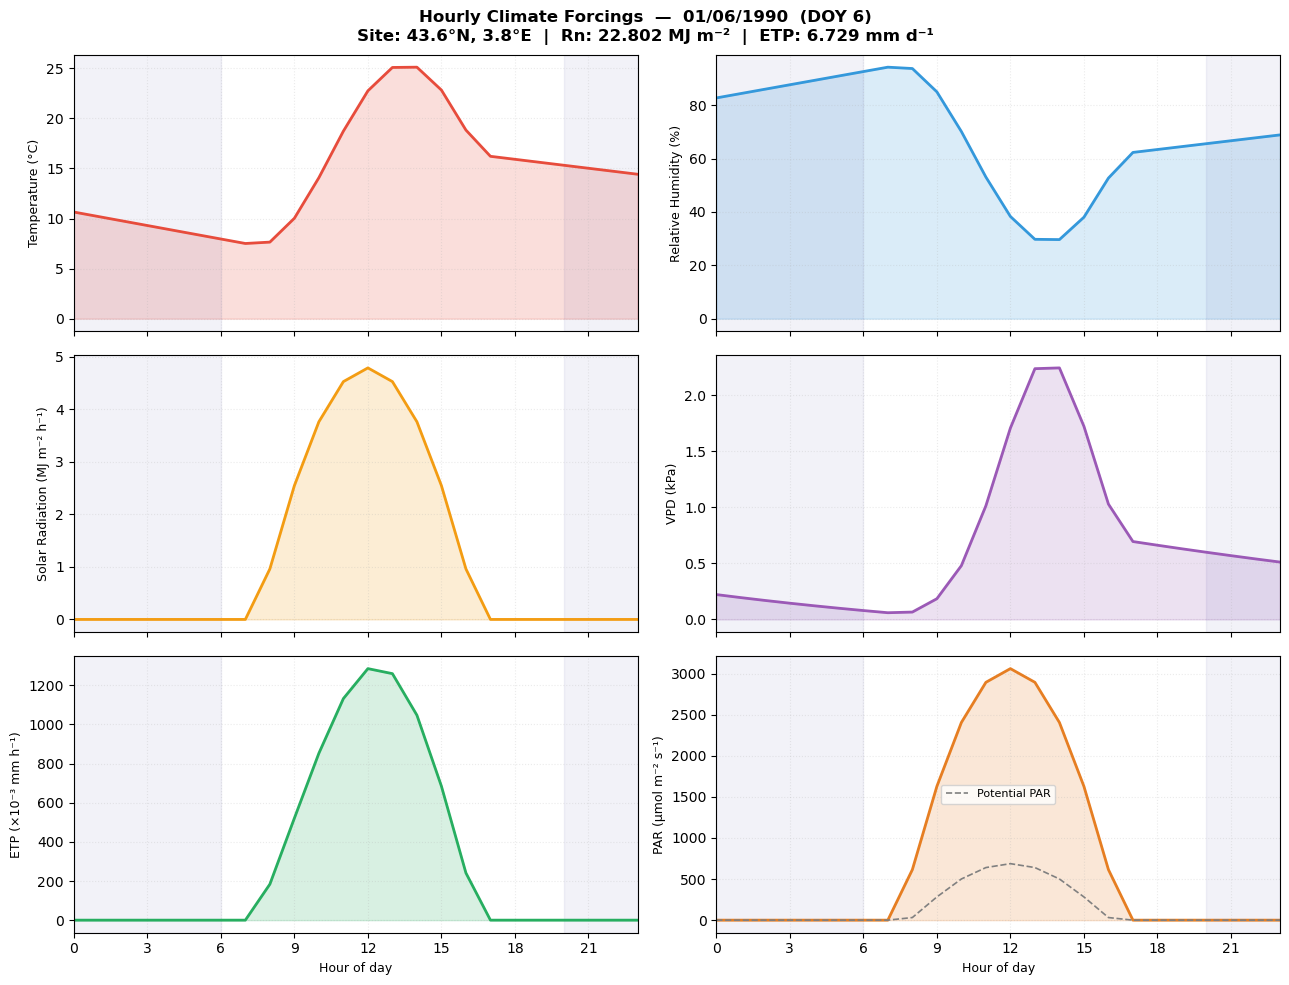

In [ ]:
fig1, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
fig1.suptitle(
    f"Hourly Climate Forcings  —  {target_date}  (DOY {clim.DOY})\n"
    f"Site: {opts.latitude}°N, {opts.longitude}°E  |  Rn: {clim.net_radiation:.3f} MJ m⁻²  |  "
    f"ETP: {clim.ETP:.3f} mm d⁻¹",
    fontsize=12,
    fontweight="bold",
)

panels = [
    (axes[0, 0], hourly_ch.T_air_mean, "Temperature (°C)", COLORS["T"], None),
    (axes[0, 1], hourly_ch.RH_air_mean, "Relative Humidity (%)", COLORS["RH"], None),
    (axes[1, 0], hourly_ch.RG, "Solar Radiation (MJ m⁻² h⁻¹)", COLORS["Rg"], None),
    (axes[1, 1], hourly_ch.VPD, "VPD (kPa)", COLORS["VPD"], None),
    (axes[2, 0], hourly_ch.ETP * 1000, "ETP (×10⁻³ mm h⁻¹)", COLORS["ETP"], None),
    (
        axes[2, 1],
        hourly_ch.PAR,
        "PAR (µmol m⁻² s⁻¹)",
        COLORS["PAR"],
        hourly_ch.potential_PAR,
    ),
]

for ax, y, ylabel, color, y2 in panels:
    ax.fill_between(HOURS, y, alpha=0.18, color=color)
    ax.plot(HOURS, y, color=color, lw=2)
    if y2 is not None:
        ax.plot(HOURS, y2, color="gray", lw=1.2, ls="--", label="Potential PAR")
        ax.legend(fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlim(0, 23)
    ax.grid(True, alpha=0.25, ls=":")
    ax.axvspan(0, clim.DOY and 6, alpha=0.05, color="navy")  # night shading
    ax.axvspan(20, 23, alpha=0.05, color="navy")

for ax in axes[2, :]:
    ax.set_xlabel("Hour of day", fontsize=9)
    ax.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

#### Figure 2: Multi-day comparison (week)

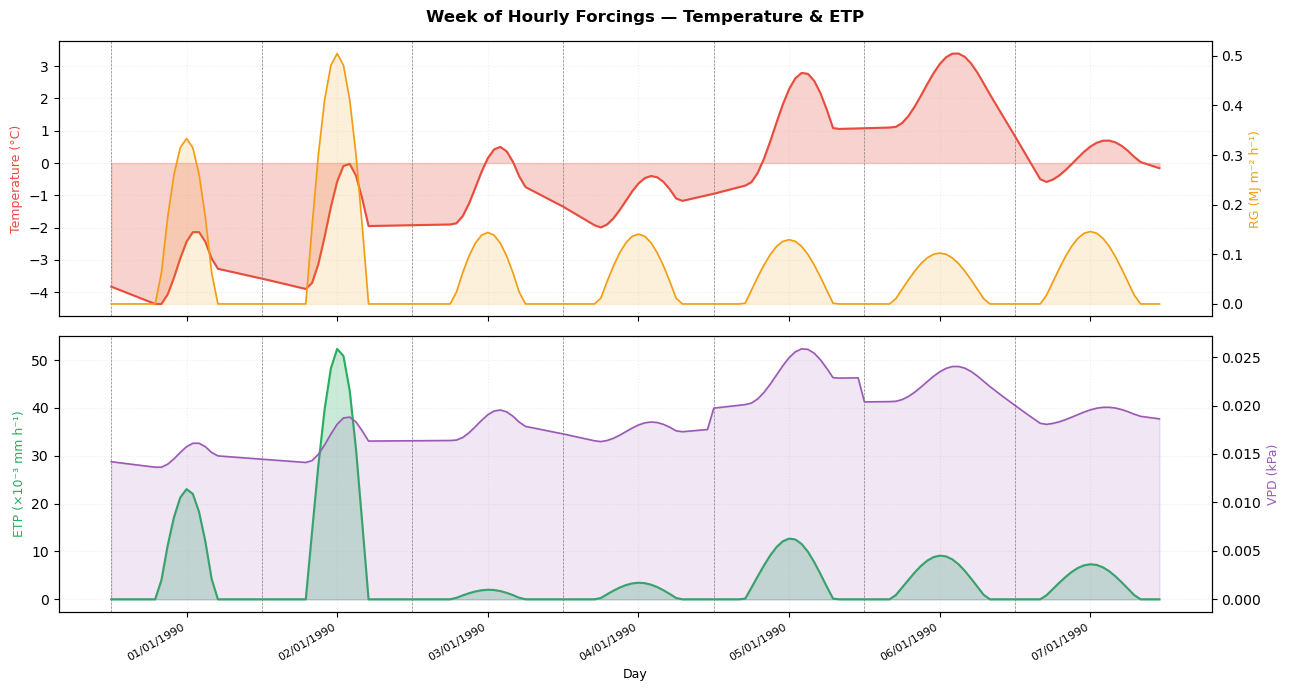

In [ ]:
n_days = len(week_dates)
fig2, axes2 = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig2.suptitle(
    "Week of Hourly Forcings — Temperature & ETP", fontsize=12, fontweight="bold"
)

all_T = []
all_ETP = []
all_VPD = []
all_RG = []
x_ticks = []
x_labels = []

for i, date in enumerate(week_dates):
    c = new_climate_day(climate_df, date)
    c = compute_Rn_and_ETP(c, veg_params, opts)
    h = new_climate_hourly(c, opts, veg_params)
    offset = i * 24
    x = np.arange(offset, offset + 24)
    all_T.extend(h.T_air_mean)
    all_ETP.extend(h.ETP)
    all_RG.extend(h.RG)
    all_VPD.extend(h.VPD)
    x_ticks.append(offset + 12)
    x_labels.append(date)

X = np.arange(len(all_T))

ax = axes2[0]
ax.fill_between(X, all_T, alpha=0.25, color=COLORS["T"])
ax.plot(X, all_T, color=COLORS["T"], lw=1.5, label="Temperature")
ax2r = ax.twinx()
ax2r.fill_between(X, all_RG, alpha=0.15, color=COLORS["Rg"])
ax2r.plot(X, all_RG, color=COLORS["Rg"], lw=1.2, label="Solar Rad.")
ax.set_ylabel("Temperature (°C)", color=COLORS["T"], fontsize=9)
ax2r.set_ylabel("RG (MJ m⁻² h⁻¹)", color=COLORS["Rg"], fontsize=9)
ax.grid(True, alpha=0.2, ls=":")
for d in range(n_days):
    ax.axvline(d * 24, color="gray", lw=0.5, ls="--")

ax = axes2[1]
ax.fill_between(X, [e * 1000 for e in all_ETP], alpha=0.25, color=COLORS["ETP"])
ax.plot(X, [e * 1000 for e in all_ETP], color=COLORS["ETP"], lw=1.5, label="ETP")
ax2r2 = ax.twinx()
ax2r2.fill_between(X, all_VPD, alpha=0.15, color=COLORS["VPD"])
ax2r2.plot(X, all_VPD, color=COLORS["VPD"], lw=1.2, label="VPD")
ax.set_ylabel("ETP (×10⁻³ mm h⁻¹)", color=COLORS["ETP"], fontsize=9)
ax2r2.set_ylabel("VPD (kPa)", color=COLORS["VPD"], fontsize=9)
ax.set_xlabel("Day", fontsize=9)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=8)
ax.grid(True, alpha=0.2, ls=":")
for d in range(n_days):
    ax.axvline(d * 24, color="gray", lw=0.5, ls="--")

plt.tight_layout()
plt.show()

#### Figure 3: ETP_formulation comparison PT vs PM

ETP_formulation is PM
Remember to adjust the lat/lon


<function matplotlib.pyplot.show(close=None, block=None)>

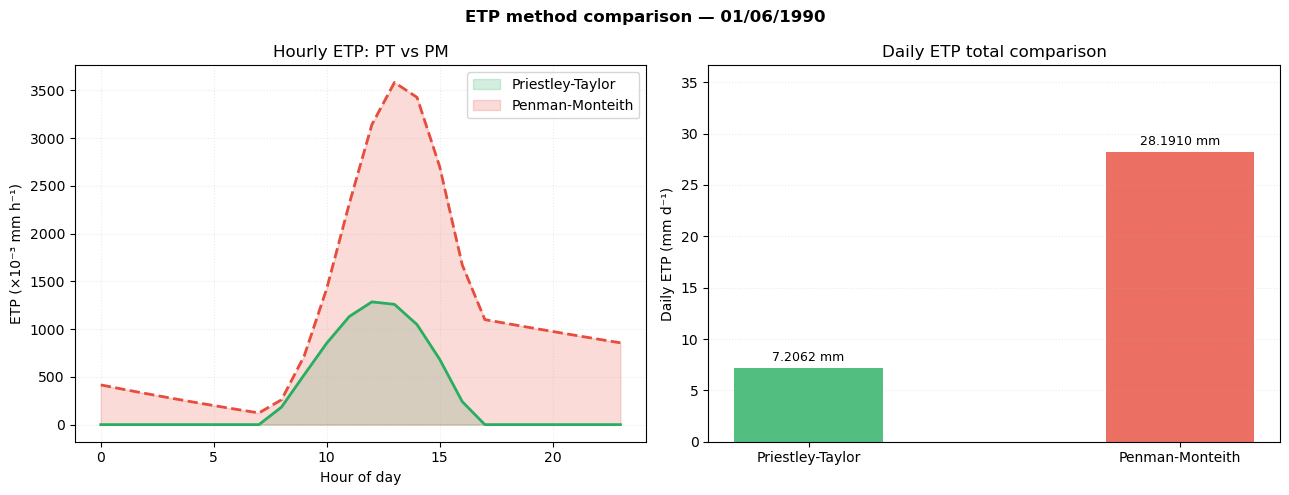

In [ ]:
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle(f"ETP method comparison — {target_date}", fontsize=12, fontweight="bold")

# PT
opts_pt = SurEauModelOptions(**{**vars(opts), "ETP_formulation": "PT"})
c_pt = new_climate_day(climate_df, target_date)
c_pt = compute_Rn_and_ETP(c_pt, veg_params, opts_pt)
h_pt = new_climate_hourly(c_pt, opts_pt, veg_params)

# PM
opts_pm = SurEauModelOptions(**{**vars(opts), "ETP_formulation": "PM"})
c_pm = new_climate_day(climate_df, target_date)
c_pm = compute_Rn_and_ETP(c_pm, veg_params, opts_pm)
h_pm = new_climate_hourly(c_pm, opts_pm, veg_params)

ax = axes3[0]
ax.fill_between(
    HOURS, h_pt.ETP * 1000, alpha=0.2, color=COLORS["ETP"], label="Priestley-Taylor"
)
ax.plot(HOURS, h_pt.ETP * 1000, color=COLORS["ETP"], lw=2)
ax.fill_between(
    HOURS, h_pm.ETP * 1000, alpha=0.2, color="#e74c3c", label="Penman-Monteith"
)
ax.plot(HOURS, h_pm.ETP * 1000, color="#e74c3c", lw=2, ls="--")
ax.set_xlabel("Hour of day")
ax.set_ylabel("ETP (×10⁻³ mm h⁻¹)")
ax.set_title("Hourly ETP: PT vs PM")
ax.legend()
ax.grid(True, alpha=0.25, ls=":")

# Bar comparison daily totals
ax2 = axes3[1]
methods = ["Priestley-Taylor", "Penman-Monteith"]
daily_totals = [float(np.nansum(h_pt.ETP)), float(np.nansum(h_pm.ETP))]
bars = ax2.bar(
    methods, daily_totals, color=[COLORS["ETP"], "#e74c3c"], alpha=0.8, width=0.4
)
ax2.bar_label(bars, fmt="%.4f mm", padding=3, fontsize=9)
ax2.set_ylabel("Daily ETP (mm d⁻¹)")
ax2.set_title("Daily ETP total comparison")
ax2.set_ylim(0, max(daily_totals) * 1.3)
ax2.grid(True, alpha=0.25, ls=":", axis="y")

plt.tight_layout()
plt.show